# 06 — Posterior Inference

This notebook analyzes the posterior output of the Dirichlet Process (DP) survival model.

The goals are to:

- summarize posterior distributions of key parameters  
- interpret mixture weights and component structure  
- examine uncertainty in the survival function  
- understand how the DP model captures heterogeneity in survival  

We focus on extracting interpretable quantities from the posterior samples rather than fitting new models.

In [4]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import arviz as az

# Load saved posterior trace
from pathlib import Path

trace_path = Path("../data/outputs/dp_survival_trace_pilot.nc")
trace = az.from_netcdf(trace_path)

print("Trace loaded.")

Trace loaded.


In [5]:
# Basic posterior summary

az.summary(
    trace,
    var_names=["alpha", "pi", "lambda_k_raw", "rho_k_raw"],
    round_to=3
)

arviz - WARNING - Shape validation failed: input_shape: (1, 150), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.848,0.409,0.199,1.612,0.041,0.031,98.690,130.553,NaN
pi[0],0.906,0.096,0.734,0.997,0.012,0.013,54.590,57.516,NaN
pi[1],0.054,0.076,0.000,0.210,0.009,0.014,79.572,60.696,NaN
pi[2],0.022,0.044,0.000,0.079,0.005,0.010,63.982,66.938,NaN
pi[3],0.009,0.016,0.000,0.033,0.002,0.004,32.594,86.866,NaN
pi[4],0.008,0.013,0.000,0.036,0.001,0.001,56.714,74.087,NaN
lambda_k_raw[0],4894.200,571.169,3937.243,6063.831,42.228,37.870,182.237,113.068,NaN
lambda_k_raw[1],1428.595,1324.114,14.301,3900.280,134.226,156.780,68.984,49.532,NaN
lambda_k_raw[2],1182.562,1055.799,3.805,3157.872,113.311,74.371,74.672,67.490,NaN
lambda_k_raw[3],1232.942,1092.883,81.329,3484.761,130.062,94.245,57.554,106.430,NaN


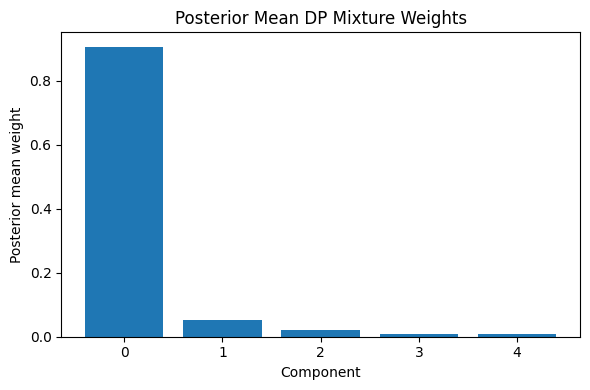

array([0.90643125, 0.05365453, 0.02241209, 0.00910614, 0.00839599])

In [6]:
# Posterior mean mixture weights

pi_mean = trace.posterior["pi"].mean(dim=("chain", "draw")).values

plt.figure(figsize=(6,4))
plt.bar(np.arange(len(pi_mean)), pi_mean)

plt.xlabel("Component")
plt.ylabel("Posterior mean weight")
plt.title("Posterior Mean DP Mixture Weights")

plt.tight_layout()
plt.show()

pi_mean

In [7]:
# Posterior means of component parameters

lambda_mean = trace.posterior["lambda_k_raw"].mean(dim=("chain", "draw")).values
rho_mean = trace.posterior["rho_k_raw"].mean(dim=("chain", "draw")).values

for k in range(len(lambda_mean)):
    print(f"Component {k}: lambda = {lambda_mean[k]:.2f}, rho = {rho_mean[k]:.2f}")

Component 0: lambda = 4894.20, rho = 1.76
Component 1: lambda = 1428.59, rho = 1.46
Component 2: lambda = 1182.56, rho = 1.89
Component 3: lambda = 1232.94, rho = 1.49
Component 4: lambda = 1104.03, rho = 1.93


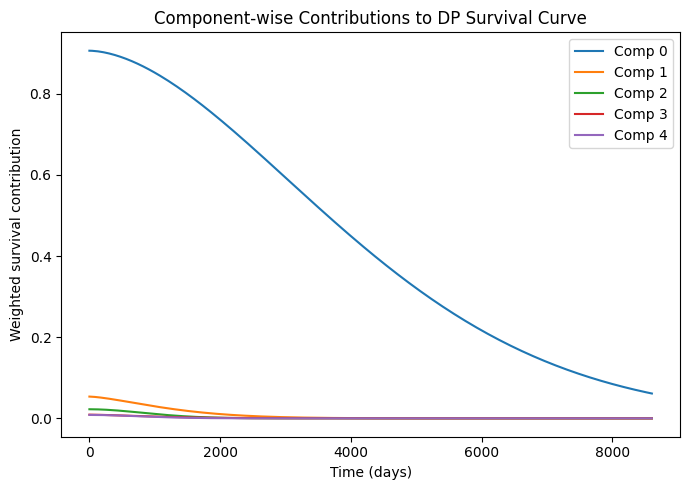

In [8]:
# Posterior mean survival contributions by component
from pathlib import Path

data_path = Path("../data/processed/tcga_brca_survival_cleaned.csv")
df = pd.read_csv(data_path)

df["time_days_adj"] = df["time_days"].copy()
df.loc[df["time_days_adj"] <= 0, "time_days_adj"] = 0.5

df_pilot = df.sample(n=250, random_state=733).copy()

t_grid = np.linspace(1, df_pilot["time_days"].max(), 200)

plt.figure(figsize=(7,5))

for k in range(len(pi_mean)):
    S_k = np.exp(-(t_grid / lambda_mean[k]) ** rho_mean[k])
    plt.plot(t_grid, pi_mean[k] * S_k, label=f"Comp {k}")

plt.xlabel("Time (days)")
plt.ylabel("Weighted survival contribution")
plt.title("Component-wise Contributions to DP Survival Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# Effective number of active components
threshold = 0.05
active_components = (pi_mean > threshold).sum()
print("Number of active components (weight > 0.05):", active_components)
print("Weights:", pi_mean)

Number of active components (weight > 0.05): 2
Weights: [0.90643125 0.05365453 0.02241209 0.00910614 0.00839599]
